In [ ]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF, NeuMF
import pandas as pd
import numpy as np
import random
# import matha
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/yelp/indexed_interactions.csv",
    sep="\t",
    header=0,
    names=[ "itemID","Category", "userID","Rating", "Gender"],
)
rating_data = rating_data_pd[["userID", "itemID","Rating"]].to_numpy()
rating_data.__len__()
rating_data_pd


,itemID,Category,userID,Rating,Gender
0,0,Food & Restaurants|Drinks & Spirits,0,5,F
1,0,Food & Restaurants|Drinks & Spirits,1,4,F
2,0,Food & Restaurants|Drinks & Spirits,2,5,F
3,0,Food & Restaurants|Drinks & Spirits,3,3,M
4,0,Food & Restaurants|Drinks & Spirits,4,3,F
...,...,...,...,...,...
97986,1271,Food & Restaurants,1060,3,F
97987,1271,Food & Restaurants,161,2,M
97988,1271,Food & Restaurants,25,3,F
97989,1271,Food & Restaurants,280,4,F


In [3]:

restaurants = pd.read_csv("./cornac/data_c/yelp/i_id_mapping.csv",sep="\t",
    header=0,
    names=[ "item_id","Category","itemID"])
restaurants=restaurants.sort_values(by="itemID")

unique_categories = [
    "Active Life & Fitness",
    "Arts & Entertainment",
    "Automotive",
    "Bars & Nightlife",
    "Coffee,Tea & Desserts",
    "Drinks & Spirits",
    "Education & Learning",
    "Event Services",
    "Family & Kids",
    "Food & Restaurants",
    "Health & Beauty",
    "Home & Garden",
    "Miscellaneous",
    "Outdoor Activities",
    "Public Services & Community",
    "Shopping & Fashion",
    "Specialty Food & Groceries",
    "Sports & Recreation",
    "Technology & Electronics",
    "Travel & Transportation",
    "Asian",
]
for c in unique_categories:
    restaurants[c] = 0
for index, row in restaurants.iterrows():
    cats = row["Category"].split("|")
    for cat in cats:
        restaurants.at[index, cat] = 1

cat = restaurants[unique_categories]
# cat[:1]
item_features_numpy = cat.to_numpy()
item_features = {
    str(item_id): {"category_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
# ids = list(range(0, 3416))

In [4]:
restaurants

,item_id,Category,itemID,Active Life & Fitness,Arts & Entertainment,Automotive,Bars & Nightlife,"Coffee,Tea & Desserts",Drinks & Spirits,Education & Learning,...,Home & Garden,Miscellaneous,Outdoor Activities,Public Services & Community,Shopping & Fashion,Specialty Food & Groceries,Sports & Recreation,Technology & Electronics,Travel & Transportation,Asian
0,34,Food & Restaurants|Drinks & Spirits,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,250,Food & Restaurants|Drinks & Spirits,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,759,Asian|Food & Restaurants,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1085,Food & Restaurants,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1122,Travel & Transportation,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,188255,Food & Restaurants,1267,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1268,188310,Food & Restaurants,1268,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1269,188449,Food & Restaurants|Bars & Nightlife,1269,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1270,188454,Food & Restaurants,1270,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:

users = pd.read_csv("./cornac/data_c/yelp/u_id_mapping.csv", sep="\t",header=0,
    names=[ "user_id","Gender","userID"])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
users = users.sort_values(by="userID")
users = users[["Gender", "userID"]]

user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
# print(item_features_numpy.shape)

(1316, 2)


In [6]:
# users
user_features_numpy[:,0]

array([1, 1, 1, ..., 1, 0, 0])

In [7]:
# users
item_features_numpy

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [8]:
dataset = rating_data
unique_categories.__len__()

21

In [24]:
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()
f1 = cornac.metrics.FMeasure(k=50)
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0,
    val_size=0.1,
    seed=123,
    verbose=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,fmt="UIR"
)
models = []
model_1 = UserKNN(k=20, seed=123, verbose=True)
model_2 = ItemKNN(k=20, seed=123, verbose=True)
model_3 =MF(
            k=20,
            seed=123,
            name=f"a={0} mf",
            backend="pytorch",
            verbose=True,
            optimizer="adam",batch_size=128,
            alpha=0,
            learning_rate=0.001,
            top_k=50, max_iter=15,run_mode="bce",
            # early_stopping=True
        )
model_4 = VAECF(
            k=20,
            autoencoder_structure=[60,32],
            act_fn="relu",
            likelihood="bern",
            n_epochs=50,
            batch_size=128,
            learning_rate=0.0005,
            alpha=0,
            top_k=50,
            beta=1,
            name=f"a={0} vae",
            seed=123,
            verbose=True,
            # early_stopping=True
        )
model_5 = NeuMF(num_factors=8,seed=123, layers=[32,16,8], act_fn="sigmoid", num_epochs=51, batch_size=256, num_neg=3, backend="pytorch", lr=0.001, alp=0, top_k=50, name=str(0)+ "neumf")
 
# models.append(model_1)
# models.append(model_2)
models.append(model_3)
# models.append(model_4)
# models.append(model_5)
cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, prec, hr, mrr, map, f1]
).run()


rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([   0,    0,    0, ..., 1315, 1315, 1315]), array([   0,    1,    2, ..., 1030,  793, 1250]), array([4., 5., 2., ..., 4., 5., 5.]))
Number of users = 1316
Number of items = 1272
Number of ratings = 67470
Max rating = 5.0
Min rating = 1.0
Global mean = 3.9
Global mean Imolicit= 1.0
::::::::
OrderedDict([(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 11), (12, 12), (13, 13), (14, 14), (15, 15), (16, 16), (17, 17), (18, 18), (19, 19), (20, 20), (21, 21), (22, 22), (23, 23), (24, 24), (25, 25), (26, 26), (27, 27), (28, 28), (29, 29), (30, 30), (31, 31), (32, 32), (33, 33), (34, 34), (35, 35), (36, 36), (37, 37), (38, 38), (39, 39), (40, 40), (41, 41), (42, 42), (43, 43), (44, 44), (45, 45), (46, 46), (47, 47), (48, 48), (49, 49), (50, 50), (51, 51), (52, 52), (53, 53), (54, 54), (55, 55), (56, 56), (57, 57), (58, 58), (59, 5

100%|██████████| 15/15 [00:40<00:00,  2.71s/it, loss=0.607]


[88.72200012207031, 88.71958923339844, 88.71334838867188, 88.69508361816406, 88.69140625, 88.69329833984375, 88.67759704589844, 88.71459197998047, 88.69583892822266, 88.6820297241211, 88.68392181396484, 88.68724060058594, 88.65498352050781, 88.63636016845703, 88.688232421875, 88.65079498291016, 88.67729949951172, 88.6888427734375, 88.66476440429688, 88.63992309570312, 88.68098449707031, 88.58064270019531, 88.66690063476562, 88.59637451171875, 88.65257263183594, 88.61607360839844, 88.63516235351562, 88.65868377685547, 88.60594177246094, 88.6719741821289, 88.58411407470703, 88.65142059326172, 88.59136199951172, 88.55110168457031, 88.60997772216797, 88.61339569091797, 88.60411834716797, 88.5596923828125, 88.69534301757812, 88.52542877197266, 88.53880310058594, 88.52909851074219, 88.50550079345703, 88.57130432128906, 88.57186889648438, 88.5130844116211, 88.6603012084961, 88.46080017089844, 88.56851196289062, 88.47997283935547, 88.56163024902344, 88.42633056640625, 88.52561950683594, 88.669

Ranking: 100%|██████████| 1316/1316 [00:00<00:00, 1673.45it/s]


VALIDATION:
...
       |    AUC |  F1@50 | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Time (s)
------ + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------
a=0 mf | 0.6837 | 0.0420 |      0.6786 | 0.0391 | 0.1334 |  0.0924 |       0.0254 |    0.1603 |   0.7888

TEST:
...
       |    AUC |  F1@50 | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
------ + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 mf | 0.6842 | 0.0713 |      0.8587 | 0.0558 | 0.2198 |  0.1209 |       0.0495 |    0.1621 |   40.6085 |   0.9427



In [25]:
user_ids = users.to_numpy()[:, 1]
item_ids = restaurants.to_numpy()[:, 2]
print(len(user_ids))
print(len(item_ids))
print(user_ids)
print(item_ids)

1316
1272
[   0    1    2 ... 1313 1314 1315]
[0 1 2 ... 1269 1270 1271]


In [17]:
# models[0].save("./saved")
import pickle

with open('mf100kyelp.pkl', 'wb') as f:
    # Pickle the 'data' dictionary using the highest protocol available.
    pickle.dump(models, f, pickle.HIGHEST_PROTOCOL)


In [27]:
reco_matrix_old = reco_matrix
reco_matrix_all_old = reco_matrix_all

In [28]:
user_ids = users.to_numpy()[:, 1]
item_ids = restaurants.to_numpy()[:, 2]
item_ids.__len__()
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [30]:
new_reco_matrix = np.zeros((5, len(user_ids), top_k), dtype=int)
new_reco_matrix_all = np.zeros((5, len(user_ids), len(item_ids)), dtype=int)
new_reco_matrix[0] = reco_matrix_old[0] #iknn
new_reco_matrix[1] = reco_matrix_old[1] #userknn
new_reco_matrix[2] = reco_matrix[0] #mf
new_reco_matrix[3] = reco_matrix_old[3] #vaecf
new_reco_matrix[4] = reco_matrix_old[4] #neumf

new_reco_matrix_all[0] = reco_matrix_all_old[0] #iknn
new_reco_matrix_all[1] = reco_matrix_all_old[1] #userknn
new_reco_matrix_all[2] = reco_matrix_all[0] #mf
new_reco_matrix_all[3] = reco_matrix_all_old[3] #vaecf
new_reco_matrix_all[4] = reco_matrix_all_old[4] #neumf

In [13]:
np.save("reco_matrix_uknn_iknn.npy", reco_matrix)
# np.save("reco_matrix_mapped_items.npy", reco_matrix_mapped_items)
# np.save("reco_matrix_mapped_scores.npy", reco_matrix_mapped_scores)
np.save("reco_matrix_all_uknn_iknn.npy", reco_matrix_all)
# np.save("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [31]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMapEdited import GenreMapEdited
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision


top_k = 50
###intialize them
gp = GenrePrecision(users, unique_categories, top_k)
gr = GenreRecall(users, unique_categories, top_k)
gm = GenreMapEdited(users, unique_categories, top_k)
gndcg = GenreNDCG(users, unique_categories, top_k)
gmrr = GenreMRR(users, unique_categories, top_k)

In [38]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(new_reco_matrix)):
    ####Precision####
    model_gps.append(gp.compute(new_reco_matrix[i], restaurants))
    model_grs.append(gr.compute(new_reco_matrix[i], restaurants))
    model_gms.append(gm.compute(new_reco_matrix[i], restaurants))
    model_gdcgs.append(gndcg.compute(new_reco_matrix[i], restaurants))
    model_gmrrs.append(gmrr.compute(new_reco_matrix[i], restaurants))


restaurants = restaurants.rename(columns={"Category": "genres"})
# ####IR Metrics####
# ####Rprecision####
model_grps = []
# for i in range(len(models)):
#     model_grps.append(grp.compute(reco_matrix_top_r[i], restaurants_df, restaurants))


In [39]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = restaurants[unique_categories].div(restaurants[unique_categories].sum(axis=1), axis=0)
movies_df = movies_df[unique_categories].sum()
import math
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(new_reco_matrix), len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(len(new_reco_matrix)):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = new_reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_categories, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [40]:
model_grps = []
for i in range(len(new_reco_matrix)):
    model_grps.append(grp.compute(reco_matrix_top_r[i], movies_df, restaurants))

        Active Life & Fitness  Arts & Entertainment  Automotive  \
Gender                                                            
0                    0.027660              0.097926         0.0   
1                    0.028587              0.097447         0.0   

        Bars & Nightlife  Coffee,Tea & Desserts  Drinks & Spirits  \
Gender                                                              
0               0.090158               0.125350          0.006233   
1               0.089913               0.126682          0.006946   

        Education & Learning  Event Services  Family & Kids  \
Gender                                                        
0                        0.0        0.023740            0.0   
1                        0.0        0.022925            0.0   

        Food & Restaurants  ...  Home & Garden  Miscellaneous  \
Gender                      ...                                 
0                 0.529896  ...            0.0       0.002658   
1     

In [42]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(reco_matrix))]
gr_sum = [sum(abs(model_grs[i])) for i in range(len(reco_matrix))]
gm_sum = [sum(abs(model_gms[i])) for i in range(len(reco_matrix))]
gdcg_sum = [sum(abs(model_gdcgs[i])) for i in range(len(reco_matrix))]
gmrr_sum = [sum(abs(model_gmrrs[i])) for i in range(len(reco_matrix))]
grp_sum = [sum(abs(model_grps[i])) for i in range(len(reco_matrix))]


In [43]:
from operator import itemgetter

# unique_genres
indices = [4, 1, 19, 20]

compare_genres = itemgetter(*indices)(unique_categories)
# compare_genres = unique_genres
# indices = range(18)
# alpha_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99999999999]

list(compare_genres)

['Coffee,Tea & Desserts',
 'Arts & Entertainment',
 'Travel & Transportation',
 'Asian']

['UserKNN', 'ItemKNN', 'MF', 'VAECF', 'NeuMF']
[<BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>]


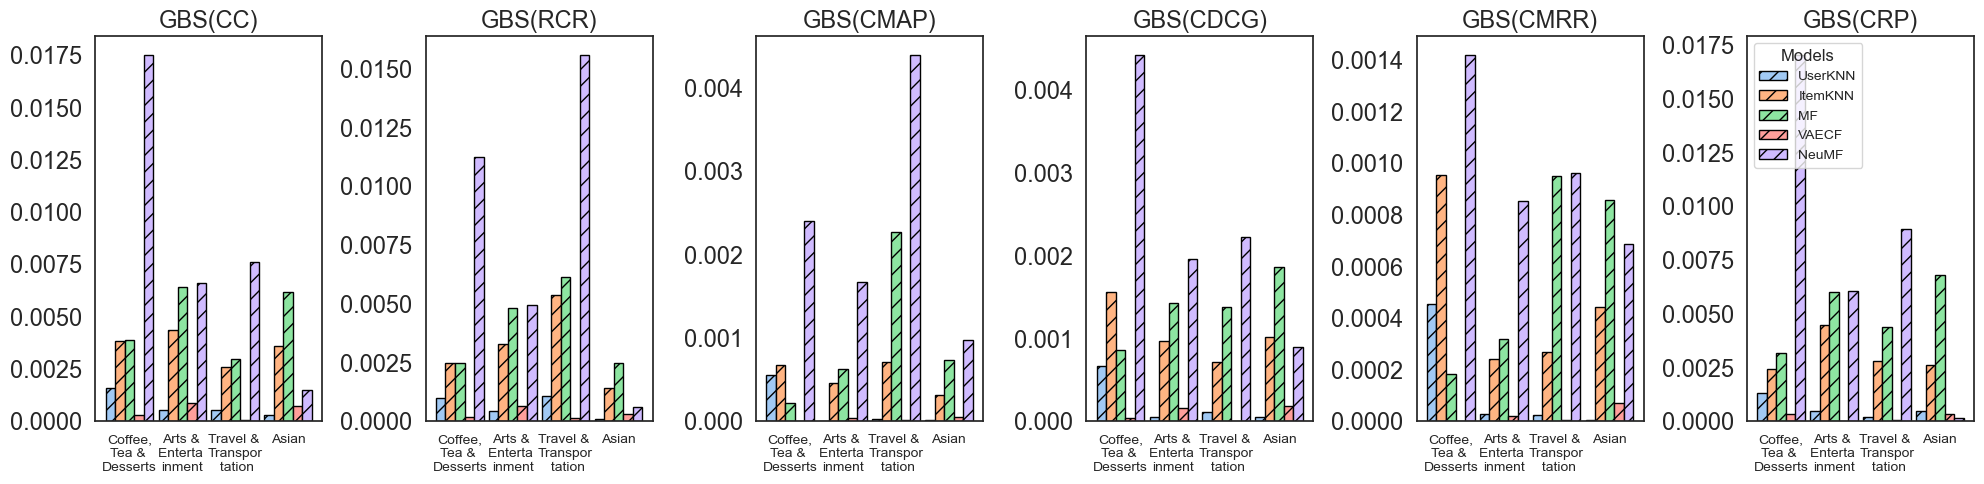

In [44]:
import matplotlib.pyplot as plt
import numpy as np
sns.set(style="white")
pastel_colors = sns.color_palette("pastel")

# alpha_values =[0,0.1,0.2,0.3,0.4,0.5,0.6]
matrices = [
    model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
matrices_2 = [
    model_gps[1][indices],
    model_grs[1][indices],
    model_gms[1][indices],
    model_gdcgs[1][indices],
    model_gmrrs[1][indices],
    model_grps[1][indices],
]
matrices_3 = [
    model_gps[2][indices],
    model_grs[2][indices],
    model_gms[2][indices],
    model_gdcgs[2][indices],
    model_gmrrs[2][indices],
    model_grps[2][indices],
]
matrices_4 = [
    model_gps[3][indices],
    model_grs[3][indices],
    model_gms[3][indices],
    model_gdcgs[3][indices],
    model_gmrrs[3][indices],
    model_grps[3][indices],
]
matrices_5 = [
    model_gps[4][indices],
    model_grs[4][indices],
    model_gms[4][indices],
    model_gdcgs[4][indices],
    model_gmrrs[4][indices],
    model_grps[4][indices],
]

labels = compare_genres
titles = [
    "GBS(CC)",
    "GBS(RCR)",
    "GBS(CMAP)",
    "GBS(CDCG)",
    "GBS(CMRR)",
    "GBS(CRP)",
]

fig, axs = plt.subplots(1,6, figsize=(20, 5))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.18  # the width of the bars
bar_spacing =0.0
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
hatches = ['//', '\\\\', '||', '--', '++']

for i in range(len(titles)):
    axs[i].bar(
        x - 2 * (bar_width + bar_spacing), abs(matrices[i]), bar_width, color=pastel_colors[0],
        edgecolor='black', hatch=hatches[0], label="UserKNN"
    )
    axs[i].bar(
        x - 1 * (bar_width + bar_spacing), abs(matrices_2[i]), bar_width, color=pastel_colors[1],
        edgecolor='black', hatch=hatches[0], label="ItemKNN"
    )
    axs[i].bar(
        x + 0 * (bar_width + bar_spacing), abs(matrices_3[i]), bar_width, color=pastel_colors[2],
        edgecolor='black', hatch=hatches[0], label="MF"
    )
    axs[i].bar(
        x + 1 * (bar_width + bar_spacing), abs(matrices_4[i]), bar_width, color=pastel_colors[3],
        edgecolor='black', hatch=hatches[0], label="VAECF"
    )
    axs[i].bar(
        x + 2 * (bar_width + bar_spacing), abs(matrices_5[i]), bar_width, color=pastel_colors[4],
        edgecolor='black', hatch=hatches[0], label="NeuMF"
    )
 
    cg = ['Coffee,\nTea & \nDesserts',
    'Arts & \nEnterta \ninment',
    'Travel & \nTranspor\n tation',
    'Asian']
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(cg, rotation=90, fontsize=10)
    # axs[i].set_yticklabels( fontsize=17)
    axs[i].tick_params(axis="y", labelsize =17)
    
    # axs[i].set_y
    axs[i].set_title(titles[i], fontsize =17)
    # axs[i].set_xlabel("Genres")
    # axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=0)
    


handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)


plt.legend(handles, labels, loc="upper left", fontsize="small", title="Models")
# Adjust layout
plt.tight_layout()
plt.savefig("all_models_plain_yelp.pdf", format="pdf")

plt.show()

In [45]:
gr_sum

[0.02522746467563707]

In [46]:
model_gps

[array([ 2.76170754e-04,  5.55924441e-04,  1.57232704e-04,  6.15300331e-04,
        -1.56712248e-03, -2.71218197e-04,  0.00000000e+00,  2.36911884e-04,
        -1.22060789e-04,  4.11040256e-04,  7.76302237e-05,  5.94964171e-05,
         2.02287818e-04, -1.37356737e-04, -3.06773607e-04, -7.74001271e-05,
        -6.56334232e-04,  2.80947998e-04,  1.06830583e-05,  5.28783994e-04,
        -2.74143712e-04]),
 array([ 1.78035319e-04,  4.36408019e-03,  3.67998097e-04,  6.54372932e-04,
        -3.85812272e-03, -3.11211185e-04,  2.01451957e-05,  1.31480038e-03,
         1.82981614e-05, -3.27241407e-03,  9.19916977e-05, -6.54570158e-05,
         6.12842836e-04,  1.06711622e-04, -2.85236874e-04,  9.43136389e-04,
        -7.04662353e-04,  4.73363575e-04,  3.24170165e-04,  2.61333434e-03,
        -3.58617667e-03]),
 array([ 1.35428308e-04,  6.43957224e-03,  4.76628756e-06,  1.38200425e-03,
        -3.86759582e-03,  3.71441720e-05,  0.00000000e+00,  3.02395196e-03,
         0.00000000e+00, -7.807946

In [48]:
yelp_dataset = [matrices,matrices_2,matrices_3,matrices_4,matrices_5]

In [1]:
yelp_dataset

NameError: name 'yelp_dataset' is not defined